In [1]:
!pip -q install yfinance shap lightgbm --upgrade

import numpy as np, pandas as pd
import warnings; warnings.filterwarnings("ignore")
import yfinance as yf
import lightgbm as lgb
import shap
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform
from scipy.stats import norm, skew, kurtosis
from statsmodels.tsa.stattools import adfuller
from sklearn.feature_selection import mutual_info_regression
import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("Environment ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.3/149.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 68.2 MB/s eta 0:00:00:00:01
Environment ready.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
CFG = dict(
    UNIVERSE   = ["AAPL","MSFT","GOOGL","AMZN","NVDA","JPM","JNJ","XOM","PG","KO","WMT","UNH"],
    START      = "2016-01-01",
    END        = "2024-12-31",
    HORIZON    = 21,          # forecast 1 month ahead (~21 trading days)
    TEST_FRAC  = 0.20,        # last 20% of time = out-of-sample
    EMBARGO    = 10,          # trading days purged between train and test
    QUANTILES  = [0.1, 0.5, 0.9],
    RF_ANNUAL  = 0.02,        # risk-free for Sharpe/Sortino
    FRAC_THRESH= 1e-4,        # fractional-diff weight cutoff
)
print(CFG)

{'UNIVERSE': ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'JPM', 'JNJ', 'XOM', 'PG', 'KO', 'WMT', 'UNH'], 'START': '2016-01-01', 'END': '2024-12-31', 'HORIZON': 21, 'TEST_FRAC': 0.2, 'EMBARGO': 10, 'QUANTILES': [0.1, 0.5, 0.9], 'RF_ANNUAL': 0.02, 'FRAC_THRESH': 0.0001}


In [4]:
def load_prices(universe, start, end):
    data = {}
    for t in universe:
        df = yf.Ticker(t).history(start=start, end=end, auto_adjust=True)
        if len(df) > 250:
            data[t] = df[["Open","High","Low","Close","Volume"]].copy()
        else:
            print(f"  skip {t}: only {len(df)} rows")
    print(f"Loaded {len(data)} tickers.")
    return data

prices = load_prices(CFG["UNIVERSE"], CFG["START"], CFG["END"])
prices["AAPL"].tail(3)

Loaded 12 tickers.


,Open,High,Low,Close,Volume
Date,,,,,
2024-12-26 00:00:00-05:00,256.3298,258.2261,255.7739,257.1538,27237100
2024-12-27 00:00:00-05:00,255.9724,256.8362,251.2368,253.7486,42355300
2024-12-30 00:00:00-05:00,250.4127,251.6736,248.9434,250.3830,35557500


In [5]:
def rsi(close, n=14):
    d = close.diff()
    gain = d.clip(lower=0).ewm(alpha=1/n, adjust=False).mean()
    loss = (-d.clip(upper=0)).ewm(alpha=1/n, adjust=False).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - 100/(1+rs)

def macd_signal(close, fast=12, slow=26, sig=9):
    macd = close.ewm(span=fast, adjust=False).mean() - close.ewm(span=slow, adjust=False).mean()
    return macd - macd.ewm(span=sig, adjust=False).mean()   # histogram

def bollinger_bw(close, n=20):
    sma = close.rolling(n).mean(); sd = close.rolling(n).std()
    return (2*2*sd) / sma                                    # (upper-lower)/SMA

def atr(df, n=14):
    h,l,c = df["High"], df["Low"], df["Close"]
    tr = pd.concat([h-l, (h-c.shift()).abs(), (l-c.shift()).abs()], axis=1).max(axis=1)
    return tr.ewm(alpha=1/n, adjust=False).mean()

def stochastic_k(df, n=14):
    ll = df["Low"].rolling(n).min(); hh = df["High"].rolling(n).max()
    return 100*(df["Close"]-ll)/(hh-ll)

def obv(df):
    sign = np.sign(df["Close"].diff()).fillna(0)
    return (sign*df["Volume"]).cumsum()

def williams_r(df, n=14):
    hh = df["High"].rolling(n).max(); ll = df["Low"].rolling(n).min()
    return -100*(hh-df["Close"])/(hh-ll)

def technical_block(df):
    c = df["Close"]
    return pd.DataFrame({
        "RSI_14":       rsi(c),
        "MACD_signal":  macd_signal(c),
        "Boll_BW":      bollinger_bw(c),
        "ATR_14":       atr(df)/c,              # normalized
        "Stoch_K":      stochastic_k(df),
        "OBV_delta":    obv(df).pct_change(5),
        "Williams_R":   williams_r(df),
        "ret_5":        c.pct_change(5),
        "ret_21":       c.pct_change(21),
        "vol_21":       c.pct_change().rolling(21).std(),
    }, index=df.index)

technical_block(prices["AAPL"]).tail(3)

,RSI_14,MACD_signal,Boll_BW,ATR_14,Stoch_K,OBV_delta,Williams_R,ret_5,ret_21,vol_21
Date,,,,,,,,,,
2024-12-26 00:00:00-05:00,76.4529,0.7234,0.1063,0.0152,94.1144,0.0369,-5.8856,0.0442,0.1123,0.0086
2024-12-27 00:00:00-05:00,67.6262,0.4493,0.0983,0.0160,75.4223,0.0240,-24.5777,0.0232,0.0873,0.0094
2024-12-30 00:00:00-05:00,60.2256,-0.0124,0.0891,0.0164,46.4769,0.0016,-53.5231,-0.0090,0.0735,0.0101


In [6]:
def fundamental_snapshot(ticker):
    keys = ["trailingPE","priceToBook","returnOnEquity","debtToEquity",
            "profitMargins","dividendYield","revenueGrowth"]
    try:
        info = yf.Ticker(ticker).info
        return {k: info.get(k, np.nan) for k in keys}
    except Exception:
        return {k: np.nan for k in keys}

funda = pd.DataFrame({t: fundamental_snapshot(t) for t in prices}).T
funda = funda.apply(pd.to_numeric, errors="coerce")
funda = funda.fillna(funda.median())          # cross-sectional median impute
funda.columns = ["f_PE","f_PB","f_ROE","f_DE","f_NPM","f_DivYld","f_RevG"]
funda

,f_PE,f_PB,f_ROE,f_DE,f_NPM,f_DivYld,f_RevG
AAPL,35.5789,42.5883,1.4875,78.4450,0.2762,0.3500,0.1640
MSFT,27.3935,8.3332,0.3404,29.1180,0.4031,0.7400,0.1770
GOOGL,17.4223,6.7196,0.4868,18.8590,0.5477,0.2500,0.2420
AMZN,21.0073,5.0880,0.3056,45.6170,0.1744,0.8400,0.1960
NVDA,32.5559,25.9802,1.1429,6.5550,0.6297,0.4700,0.8520
JPM,15.2873,2.6803,0.1779,57.7090,0.3492,0.8400,0.3040
JNJ,31.6530,7.6522,0.2574,57.7090,0.2148,0.8400,0.0660
XOM,20.6514,2.5078,0.1258,15.9210,0.0907,2.5600,0.4410
PG,21.9697,6.3189,0.3029,64.4900,0.1844,2.9900,0.0150
KO,27.5474,10.7225,0.4205,115.5190,0.2856,2.3100,0.0670


In [7]:
def frac_weights(d, thresh):
    w = [1.0]; k = 1
    while True:
        w_ = -w[-1]*(d-k+1)/k
        if abs(w_) < thresh or k > 2000: break
        w.append(w_); k += 1
    return np.array(w[::-1])                    # oldest -> newest

def frac_diff(series, d, thresh):
    w = frac_weights(d, thresh); width = len(w); v = series.values
    out = np.full(len(v), np.nan)
    for i in range(width-1, len(v)):
        out[i] = w @ v[i-width+1:i+1]
    return pd.Series(out, index=series.index)

def optimal_d(series, thresh, grid=np.linspace(0,1,11), pval=0.05):
    for d in grid:
        fd = frac_diff(series, d, thresh).dropna()
        if len(fd) < 100: continue
        if adfuller(fd, maxlag=1, autolag=None)[1] < pval:
            return d
    return 1.0

# demo on one ticker, then apply per-ticker
d_star = optimal_d(np.log(prices["AAPL"]["Close"]), CFG["FRAC_THRESH"])
print(f"AAPL optimal d* = {d_star:.2f}")
raw_p = adfuller(np.log(prices['AAPL']['Close']).dropna(), maxlag=1, autolag=None)[1]
fd_p  = adfuller(frac_diff(np.log(prices['AAPL']['Close']), d_star, CFG['FRAC_THRESH']).dropna(),
                 maxlag=1, autolag=None)[1]
print(f"ADF p-value  raw log-price={raw_p:.3f}  ->  frac-diff={fd_p:.4f}")

AAPL optimal d* = 0.30
ADF p-value  raw log-price=0.857  ->  frac-diff=0.0031


In [8]:
def build_panel(prices, funda, cfg):
    frames = []
    for t, df in prices.items():
        feat = technical_block(df)
        logc = np.log(df["Close"])
        d_t  = optimal_d(logc, cfg["FRAC_THRESH"])
        feat["fracdiff_close"] = frac_diff(logc, d_t, cfg["FRAC_THRESH"])
        for col in funda.columns:                # broadcast snapshot
            feat[col] = funda.loc[t, col]
        # forward return label (strictly future -> no leakage)
        feat["fwd_ret"] = df["Close"].shift(-cfg["HORIZON"])/df["Close"] - 1
        feat["ticker"] = t
        frames.append(feat)
    panel = pd.concat(frames).dropna()
    return panel

panel = build_panel(prices, funda, CFG)
FEATURES = [c for c in panel.columns if c not in ("fwd_ret","ticker")]
print(f"Panel: {panel.shape[0]:,} rows x {len(FEATURES)} features")

def isf_mid(X, y, k, redundancy=0.5):
    rel = mutual_info_regression(X.values, y.values, random_state=0)
    rel = pd.Series(rel, index=X.columns)
    chosen = [rel.idxmax()]; pool = [c for c in X.columns if c not in chosen]
    while len(chosen) < k and pool:
        best, best_s = None, -1e9
        for j in pool:
            red = np.mean([mutual_info_regression(X[[j]].values, X[s].values,
                          random_state=0)[0] for s in chosen])
            s = rel[j] - redundancy*red
            if s > best_s: best_s, best = s, j
        chosen.append(best); pool.remove(best)
    return chosen

TOPK = isf_mid(panel[FEATURES], panel["fwd_ret"], k=12)
print("Selected features:", TOPK)

Panel: 21,491 rows x 18 features
Selected features: ['fracdiff_close', 'ret_5', 'Boll_BW', 'ATR_14', 'OBV_delta', 'RSI_14', 'MACD_signal', 'vol_21', 'f_DivYld', 'ret_21', 'Williams_R', 'f_PE']


In [9]:
def purged_split(panel, cfg):
    dates = np.sort(panel.index.unique())
    cut = dates[int(len(dates)*(1-cfg["TEST_FRAC"]))]
    gap = pd.Timedelta(days=cfg["HORIZON"]+cfg["EMBARGO"])
    train = panel[panel.index < (cut - gap)]
    test  = panel[panel.index >= cut]
    return train, test

train, test = purged_split(panel, CFG)
print(f"train rows={len(train):,}  test rows={len(test):,}")
print(f"train ends {train.index.max().date()}  |  test starts {test.index.min().date()}")

train rows=16,775  test rows=4,452
train ends 2023-05-08  |  test starts 2023-06-09


In [10]:
def train_quantile_models(train, test, features, quantiles):
    Xtr, ytr = train[features], train["fwd_ret"]
    Xte = test[features]
    preds = {}
    models = {}
    for q in quantiles:
        m = lgb.LGBMRegressor(objective="quantile", alpha=q, n_estimators=400,
                              learning_rate=0.03, num_leaves=31, subsample=0.8,
                              colsample_bytree=0.8, min_child_samples=50, verbose=-1)
        m.fit(Xtr, ytr)
        preds[q] = m.predict(Xte)
        models[q] = m
    return models, preds

models, preds = train_quantile_models(train, test, TOPK, CFG["QUANTILES"])
res = test[["ticker","fwd_ret"]].copy()
for q in CFG["QUANTILES"]:
    res[f"pred_{q}"] = preds[q]

# Confidence = how TIGHT this asset's 0.1-0.9 forecast band is versus its peers today.
# (Rank-based, so it is always populated and lives in [0,1] - more robust than dividing
#  the band by the median, which explodes when the median is near zero.)
band = res["pred_0.9"] - res["pred_0.1"]
res["confidence"] = (res.assign(_b=band)
                        .groupby(level=0)["_b"]
                        .transform(lambda b: 1 - b.rank(pct=True)))
res.tail(4)

,ticker,fwd_ret,pred_0.1,pred_0.5,pred_0.9,confidence
Date,,,,,,
2024-11-22 00:00:00-05:00,UNH,-0.1402,-0.0693,-0.0196,0.0638,0.4167
2024-11-25 00:00:00-05:00,UNH,-0.1530,-0.0724,-0.0038,0.0706,0.3333
2024-11-26 00:00:00-05:00,UNH,-0.1563,-0.0933,-0.0055,0.0615,0.1667
2024-11-27 00:00:00-05:00,UNH,-0.1621,-0.0835,-0.0052,0.0628,0.3333


signal
BUY            1544
SELL           1366
HOLD            907
STRONG_SELL     448
STRONG_BUY      187
Name: count, dtype: int64 



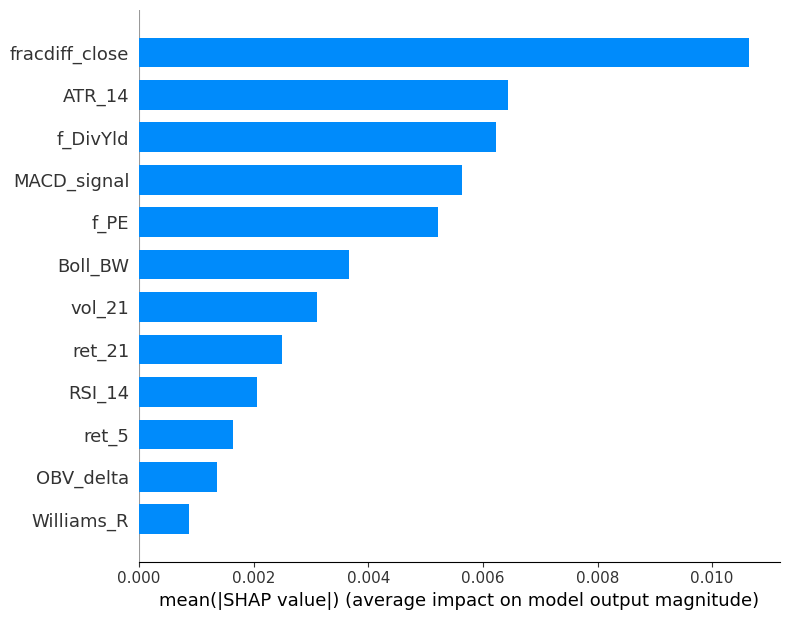

In [11]:
# --- Option A: absolute thresholds exactly as written in the doc (§4) ---
def to_signal_absolute(row):
    r, c = row["pred_0.5"], row["confidence"]
    if   r >  0.03 and c >= 0.5: return "STRONG_BUY"
    elif r >  0.01:              return "BUY"
    elif r < -0.03 and c >= 0.5: return "STRONG_SELL"
    elif r < -0.01:              return "SELL"
    else:                        return "HOLD"

# --- Option B: cross-sectional (recommended). Ranks each day's predictions, so you
#     always get a balanced, actionable spread of Buys/Sells instead of (on some days)
#     everything landing in HOLD. This is what the recommendation report uses. ---
def assign_signals_cross_sectional(res, buy_z=0.3, strong_z=1.0, conf_min=0.5):
    def per_day(gp):
        z = (gp["pred_0.5"] - gp["pred_0.5"].mean()) / (gp["pred_0.5"].std() + 1e-9)
        sig = pd.Series("HOLD", index=gp.index)
        sig[z >  buy_z] = "BUY";  sig[z < -buy_z] = "SELL"
        sig[(z >  strong_z) & (gp["confidence"] >= conf_min)] = "STRONG_BUY"
        sig[(z < -strong_z) & (gp["confidence"] >= conf_min)] = "STRONG_SELL"
        gp = gp.copy(); gp["signal"] = sig; return gp
    return res.groupby(level=0, group_keys=False).apply(per_day)

res = assign_signals_cross_sectional(res)
print(res["signal"].value_counts(), "\n")

explainer = shap.TreeExplainer(models[0.5])
shap_vals = explainer.shap_values(test[TOPK])
shap.summary_plot(shap_vals, test[TOPK], plot_type="bar", show=True)

In [12]:
def hrp_weights(cov):
    cov = np.asarray(cov)
    std = np.sqrt(np.diag(cov)); corr = cov/np.outer(std,std)
    dist = np.sqrt(0.5*(1-np.clip(corr,-1,1)))
    link = linkage(squareform(dist, checks=False), method="single")
    n = cov.shape[0]
    def quasi(link):
        link = link.astype(int); s = pd.Series([link[-1,0],link[-1,1]]); ni = link[-1,3]
        while s.max() >= ni:
            s.index = range(0, s.shape[0]*2, 2)
            df0 = s[s>=ni]; i=df0.index; j=df0.values-ni
            s[i]=link[j,0]; s=pd.concat([s,pd.Series(link[j,1],index=i+1)]).sort_index()
            s.index = range(s.shape[0])
        return s.tolist()
    def cvar(cov, items):
        c = cov[np.ix_(items,items)]; iv = 1/np.diag(c); iv/=iv.sum()
        return float(iv @ c @ iv)
    order = quasi(link); w = pd.Series(1.0, index=order); clusters=[order]
    while clusters:
        clusters = [c[a:b] for c in clusters for a,b in
                    ((0,len(c)//2),(len(c)//2,len(c))) if len(c)>1]
        for i in range(0,len(clusters),2):
            c0,c1 = clusters[i],clusters[i+1]
            v0,v1 = cvar(cov,c0),cvar(cov,c1); a = 1-v0/(v0+v1)
            w[c0]*=a; w[c1]*=1-a
    return w.sort_index().values

def mvo_weights(mu, cov, gamma=5.0):
    inv = np.linalg.pinv(cov)                    # pinv = numerically safer
    raw = inv @ mu / gamma
    w = np.clip(raw, 0, None); s = w.sum()
    return w/s if s>0 else np.ones_like(w)/len(w)

# latest cross-section of longs
last_day = res.index.max()
longs = res[(res.index==last_day) & res["signal"].isin(["BUY","STRONG_BUY"])]["ticker"].tolist()
if len(longs) < 3:                               # fallback so the demo always allocates
    longs = res[res.index==last_day].nlargest(5,"pred_0.5")["ticker"].tolist()

rets = pd.DataFrame({t: prices[t]["Close"].pct_change() for t in longs}).dropna()
cov  = rets.cov().values*252
mu   = rets.mean().values*252

w_hrp = hrp_weights(cov)
w_mvo = mvo_weights(mu, cov)
alloc = pd.DataFrame({"ticker":longs,"HRP":w_hrp,"MVO":w_mvo}).set_index("ticker")
print("Selected longs:", longs)
alloc.round(3)

Selected longs: ['AAPL', 'MSFT', 'NVDA', 'XOM', 'KO']


,HRP,MVO
ticker,,
AAPL,0.1130,0.2780
MSFT,0.1270,0.0000
NVDA,0.0630,0.5220
XOM,0.2030,0.0320
KO,0.4950,0.1680


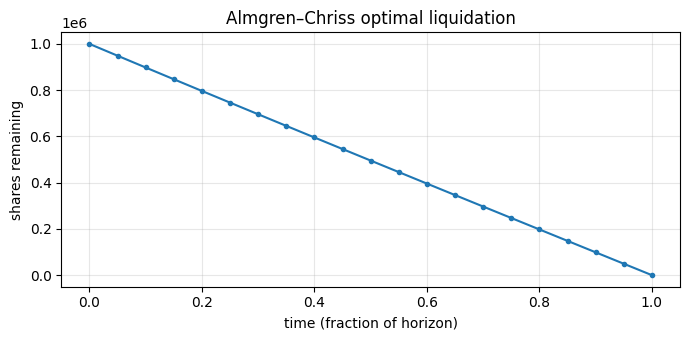

First slice sells 51,106 sh; last slice 49,406 sh (front-loaded).


In [13]:
def almgren_chriss(X0, T, steps, sigma, eta, lam):
    kappa = np.sqrt(lam*sigma**2/eta)
    t = np.linspace(0, T, steps+1)
    holdings = X0*np.sinh(kappa*(T-t))/np.sinh(kappa*T)
    trades = -np.diff(holdings)                  # shares executed each slice
    return t, holdings, trades

t, hold, trades = almgren_chriss(X0=1_000_000, T=1.0, steps=20,
                                 sigma=0.30, eta=2.5e-6, lam=2e-6)
plt.figure(figsize=(7,3.5))
plt.plot(t, hold, marker="o", ms=3)
plt.title("Almgren–Chriss optimal liquidation"); plt.xlabel("time (fraction of horizon)")
plt.ylabel("shares remaining"); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print(f"First slice sells {trades[0]:,.0f} sh; last slice {trades[-1]:,.0f} sh (front-loaded).")

Out-of-sample HRP portfolio
  CAGR    :  0.1553
  Sharpe  :  1.3044
  Sortino :  2.0693
  MaxDD   :  0.0909
  PSR     :  0.9651
  DSR     :  0.0000   (not significant at 0.95)


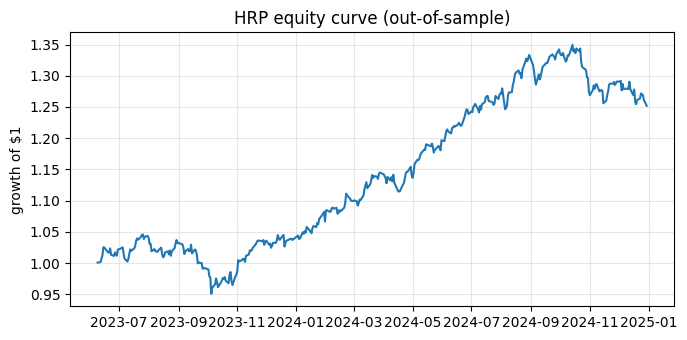

In [14]:
def perf_metrics(r, rf_annual, freq=252):
    r = np.asarray(r); rf = rf_annual/freq; ex = r-rf
    cagr = np.prod(1+r)**(freq/len(r))-1
    sharpe  = ex.mean()/ex.std(ddof=1)*np.sqrt(freq)
    downside= np.minimum(0,ex).std(ddof=1)
    sortino = ex.mean()/downside*np.sqrt(freq)
    curve = np.cumprod(1+r); mdd = np.max((np.maximum.accumulate(curve)-curve)/np.maximum.accumulate(curve))
    return dict(CAGR=cagr, Sharpe=sharpe, Sortino=sortino, MaxDD=mdd), curve

def psr(r, sr_star=0.0):
    r=np.asarray(r); n=len(r); sr=r.mean()/r.std(ddof=1)
    g3=skew(r); g4=kurtosis(r,fisher=False)
    return float(norm.cdf((sr-sr_star)*np.sqrt(n-1)/np.sqrt(1-g3*sr+(g4-1)/4*sr**2)))

def deflated_sr(r, n_trials):
    r=np.asarray(r); sr=r.mean()/r.std(ddof=1)
    # expected max Sharpe under n_trials independent strategies (López de Prado)
    e = 0.5772; z1=norm.ppf(1-1/n_trials); z2=norm.ppf(1-1/(n_trials*np.e))
    sr0 = (1-e)*z1 + e*z2
    return psr(r, sr0)

# realized daily return of the HRP book over the test window
test_dates = rets.loc[rets.index >= last_day - pd.Timedelta(days=400)].index
book = (rets[longs] * w_hrp).sum(axis=1).loc[rets.index >= test.index.min()]
m, curve = perf_metrics(book.values, CFG["RF_ANNUAL"])
p  = psr(book.values, 0.0)
d  = deflated_sr(book.values, n_trials=len(CFG["QUANTILES"])*len(TOPK))

print("Out-of-sample HRP portfolio")
for k,v in m.items(): print(f"  {k:8s}: {v: .4f}")
print(f"  PSR     : {p: .4f}")
print(f"  DSR     : {d: .4f}   ({'PASS' if d>0.95 else 'not significant'} at 0.95)")

plt.figure(figsize=(7,3.5)); plt.plot(book.index, curve)
plt.title("HRP equity curve (out-of-sample)"); plt.ylabel("growth of $1"); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [15]:
def run_pipeline(cfg):
    prices = load_prices(cfg["UNIVERSE"], cfg["START"], cfg["END"])
    funda  = pd.DataFrame({t: fundamental_snapshot(t) for t in prices}).T
    funda  = funda.apply(pd.to_numeric, errors="coerce")
    funda  = funda.fillna(funda.median())
    funda.columns = ["f_PE","f_PB","f_ROE","f_DE","f_NPM","f_DivYld","f_RevG"]
    panel  = build_panel(prices, funda, cfg)
    feats  = [c for c in panel.columns if c not in ("fwd_ret","ticker")]
    topk   = isf_mid(panel[feats], panel["fwd_ret"], k=12)
    tr, te = purged_split(panel, cfg)
    mdls, pr = train_quantile_models(tr, te, topk, cfg["QUANTILES"])
    out = te[["ticker","fwd_ret"]].copy()
    for q in cfg["QUANTILES"]: out[f"pred_{q}"] = pr[q]
    band = out["pred_0.9"] - out["pred_0.1"]
    out["confidence"] = (out.assign(_b=band).groupby(level=0)["_b"]
                            .transform(lambda b: 1 - b.rank(pct=True)))
    out = assign_signals_cross_sectional(out)
    return dict(prices=prices, panel=panel, features=topk, models=mdls, recos=out)

# artifacts = run_pipeline(CFG)   # uncomment to run end-to-end in one call
print("Pipeline function defined. Uncomment the last line to execute.")

Pipeline function defined. Uncomment the last line to execute.


In [16]:
def generate_recommendations(res, prices, cfg, capital=1_000_000, top_n=8, asof=None):
    asof = asof or res.index.max()
    day = res[res.index == asof].copy()
    day["price"] = [float(prices[t]["Close"].asof(asof)) for t in day["ticker"]]

    # HRP weights over the recommended longs only
    longs = day[day["signal"].isin(["BUY","STRONG_BUY"])].nlargest(top_n, "pred_0.5")
    tickers = longs["ticker"].tolist(); weights = {}
    if len(tickers) >= 2:
        px = pd.DataFrame({t: prices[t]["Close"] for t in tickers})
        trail = px[px.index <= asof].pct_change().dropna().tail(252)
        weights = dict(zip(tickers, hrp_weights(trail.cov().values * 252)))
    day["target_weight"] = day["ticker"].map(weights).fillna(0.0)
    day["target_shares"] = ((day["target_weight"] * capital) / day["price"]).round(0)

    rank = {"STRONG_BUY":0,"BUY":1,"HOLD":2,"SELL":3,"STRONG_SELL":4}
    day["_o"] = day["signal"].map(rank)
    rep = (day.sort_values(["_o","pred_0.5"], ascending=[True,False])
              .rename(columns={"pred_0.5":"exp_ret_21d"}))
    return rep[["ticker","signal","exp_ret_21d","confidence","price",
                "target_weight","target_shares"]].reset_index(drop=True), asof

report, asof = generate_recommendations(res, prices, CFG, capital=1_000_000)
print(f"INVESTMENT RECOMMENDATIONS  —  as of {pd.Timestamp(asof).date()}\n")
report

INVESTMENT RECOMMENDATIONS  —  as of 2024-11-27



,ticker,signal,exp_ret_21d,confidence,price,target_weight,target_shares
0,KO,STRONG_BUY,0.0468,0.8333,61.2926,0.5031,"8,209.0000"
1,AAPL,BUY,0.0469,0.4167,233.2374,0.1085,465.0000
2,MSFT,BUY,0.0438,0.2500,417.2455,0.1434,344.0000
3,NVDA,BUY,0.0336,0.1667,135.1289,0.0326,241.0000
4,XOM,BUY,0.0230,0.6667,111.2626,0.2123,"1,908.0000"
5,JNJ,HOLD,0.0138,0.9167,148.3975,0.0000,0.0000
6,GOOGL,SELL,-0.0005,0.0833,168.1579,0.0000,0.0000
7,UNH,SELL,-0.0052,0.3333,583.5930,0.0000,0.0000
8,JPM,SELL,-0.0058,0.5833,241.1870,0.0000,0.0000
9,AMZN,SELL,-0.0060,0.0000,205.7400,0.0000,0.0000


In [17]:
def add_rationale(report, models, panel_test, features, asof, k=3):
    day = panel_test[panel_test.index == asof]
    if len(day) == 0: return report
    sv = shap.TreeExplainer(models[0.5]).shap_values(day[features])
    sv = pd.DataFrame(sv, columns=features, index=day["ticker"].values)
    reasons = {}
    for t in report["ticker"]:
        if t in sv.index:
            row = sv.loc[t]; row = row.iloc[0] if isinstance(row, pd.DataFrame) else row
            top = row.reindex(row.abs().sort_values(ascending=False).index)[:k]
            reasons[t] = ", ".join(f"{f} ({'+' if v>=0 else '−'})" for f, v in top.items())
    report = report.copy(); report["key_drivers"] = report["ticker"].map(reasons)
    return report

report = add_rationale(report, models, test, TOPK, asof)
report[["ticker","signal","exp_ret_21d","confidence","target_weight","key_drivers"]]

,ticker,signal,exp_ret_21d,confidence,target_weight,key_drivers
0,KO,STRONG_BUY,0.0468,0.8333,0.5031,"MACD_signal (+), RSI_14 (+), Boll_BW (+)"
1,AAPL,BUY,0.0469,0.4167,0.1085,"vol_21 (+), f_DivYld (+), Boll_BW (+)"
2,MSFT,BUY,0.0438,0.2500,0.1434,"MACD_signal (+), Boll_BW (+), ATR_14 (−)"
3,NVDA,BUY,0.0336,0.1667,0.0326,"ATR_14 (+), vol_21 (−), ret_5 (−)"
4,XOM,BUY,0.0230,0.6667,0.2123,"fracdiff_close (+), ATR_14 (−), f_DivYld (−)"
5,JNJ,HOLD,0.0138,0.9167,0.0000,"fracdiff_close (−), MACD_signal (+), f_PE (+)"
6,GOOGL,SELL,-0.0005,0.0833,0.0000,"fracdiff_close (−), f_DivYld (+), f_PE (−)"
7,UNH,SELL,-0.0052,0.3333,0.0000,"fracdiff_close (−), ATR_14 (−), MACD_signal (+)"
8,JPM,SELL,-0.0058,0.5833,0.0000,"fracdiff_close (−), f_PE (−), ATR_14 (−)"
9,AMZN,SELL,-0.0060,0.0000,0.0000,"fracdiff_close (−), f_PE (−), f_DivYld (+)"


In [18]:
def execution_plan(report, sigma=0.30, eta=2.5e-6, lam=2e-6, steps=10):
    rows = []
    for _, r in report[report["target_shares"] > 0].iterrows():
        _, _, trades = almgren_chriss(r["target_shares"], 1.0, steps, sigma, eta, lam)
        rows.append(dict(ticker=r["ticker"], total_shares=int(r["target_shares"]),
                         first_slice=int(round(trades[0])),
                         last_slice=int(round(trades[-1])), slices=steps))
    return pd.DataFrame(rows)

execution_plan(report)

,ticker,total_shares,first_slice,last_slice,slices
0,KO,8209,838,811,10
1,AAPL,465,47,46,10
2,MSFT,344,35,34,10
3,NVDA,241,25,24,10
4,XOM,1908,195,189,10


WALK-FORWARD BACKTEST  (18 rebalances)

  CAGR    :  0.3150
  Sharpe  :  2.7266
  Sortino :  21.6820
  MaxDD   :  0.0087
  PSR     :  1.0000
  DSR     :  0.0000


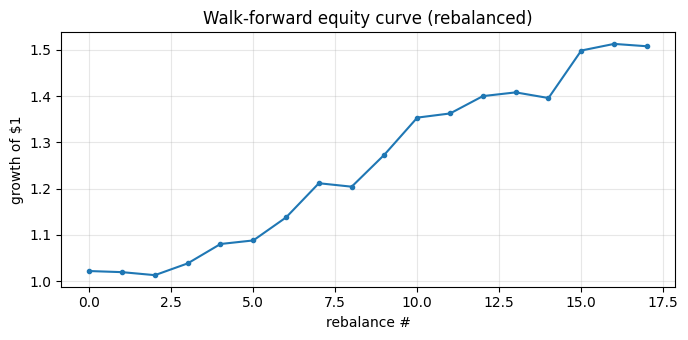

In [19]:
def walkforward_backtest(res, prices, cfg, top_n=5):
    dates = np.sort(res.index.unique()); rebal = dates[::cfg["HORIZON"]]
    period_rets, log = [], []
    for d in rebal:
        day = res[res.index == d]
        longs = day[day["signal"].isin(["BUY","STRONG_BUY"])]
        longs = (longs if len(longs) >= 3 else day).nlargest(min(top_n, len(day)), "pred_0.5")
        tk = longs["ticker"].tolist()
        if len(tk) < 2: continue
        px = pd.DataFrame({t: prices[t]["Close"] for t in tk})
        trail = px[px.index <= d].pct_change().dropna().tail(252)
        if len(trail) < 30: continue
        w = hrp_weights(trail.cov().values * 252)
        rp = float((longs.set_index("ticker").loc[tk, "fwd_ret"].values * w).sum())
        period_rets.append(rp); log.append((pd.Timestamp(d).date(), tk))
    return np.array(period_rets), log

period_rets, log = walkforward_backtest(res, prices, CFG)
freq = 252 / CFG["HORIZON"]                     # rebalances per year
m, curve = perf_metrics(period_rets, CFG["RF_ANNUAL"], freq=freq)
print(f"WALK-FORWARD BACKTEST  ({len(period_rets)} rebalances)\n")
for k, v in m.items(): print(f"  {k:8s}: {v: .4f}")
print(f"  PSR     : {psr(period_rets, 0.0): .4f}")
print(f"  DSR     : {deflated_sr(period_rets, len(CFG['QUANTILES'])*len(TOPK)): .4f}")

plt.figure(figsize=(7,3.5)); plt.plot(range(len(curve)), curve, marker="o", ms=3)
plt.title("Walk-forward equity curve (rebalanced)"); plt.xlabel("rebalance #")
plt.ylabel("growth of $1"); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## Step 19 — Re-train the production universe for India

Steps 0–18 are preserved exactly as supplied. This production handoff retrains the same validated pipeline on an Indian-market universe using Yahoo Finance NSE symbols (`.NS`). It uses the technical, fundamental, quantile-forecast, risk, and portfolio logic already defined above; it does not silently mix the original US sample with the India artifact.

Run this cell after Steps 0–18. Change `INDIA_CFG["UNIVERSE"]` if you want a different NSE universe. For exchange-grade intraday quotes, the companion app uses a broker WebSocket adapter; this notebook remains the daily research/training layer.


In [ ]:
# Broad universe: fetch the current Nifty 500 constituent file so the model covers the major Indian sectors.
# Failed or unavailable symbols are skipped. Nifty 500 is a broad investable universe, not every illiquid NSE listing.
import io
import urllib.request

NIFTY500_URL = "https://www.niftyindices.com/IndexConstituent/ind_nifty500list.csv"
FALLBACK_SECTOR_UNIVERSE = {
    "Banks & NBFC": ["HDFCBANK.NS", "ICICIBANK.NS", "SBIN.NS", "AXISBANK.NS", "KOTAKBANK.NS"],
    "IT Services": ["TCS.NS", "INFY.NS", "HCLTECH.NS", "WIPRO.NS", "TECHM.NS"],
    "Oil, Gas & Energy": ["RELIANCE.NS", "ONGC.NS", "BPCL.NS", "IOC.NS", "GAIL.NS"],
    "FMCG": ["ITC.NS", "HINDUNILVR.NS", "NESTLEIND.NS", "BRITANNIA.NS", "DABUR.NS"],
    "Automobiles": ["MARUTI.NS", "M&M.NS", "BAJAJ-AUTO.NS", "HEROMOTOCO.NS", "EICHERMOT.NS"],
    "Pharma & Healthcare": ["SUNPHARMA.NS", "CIPLA.NS", "DRREDDY.NS", "DIVISLAB.NS", "APOLLOHOSP.NS"],
    "Capital Goods & Defence": ["LT.NS", "ABB.NS", "SIEMENS.NS", "BEL.NS", "HAL.NS"],
    "Metals & Mining": ["TATASTEEL.NS", "HINDALCO.NS", "JSWSTEEL.NS", "COALINDIA.NS", "VEDL.NS"],
    "Utilities & Power": ["NTPC.NS", "POWERGRID.NS", "TATAPOWER.NS", "JSWENERGY.NS", "TORNTPOWER.NS"],
    "Consumer Discretionary & Retail": ["TITAN.NS", "TRENT.NS", "DMART.NS", "JUBLFOOD.NS", "ETERNAL.NS"],
    "Chemicals": ["PIDILITIND.NS", "SRF.NS", "UPL.NS", "PIIND.NS", "DEEPAKNTR.NS"],
    "Real Estate & Construction": ["DLF.NS", "GODREJPROP.NS", "OBEROIRLTY.NS", "PRESTIGE.NS", "PHOENIXLTD.NS"],
}

def current_india_universe():
    request = urllib.request.Request(NIFTY500_URL, headers={"User-Agent": "Mozilla/5.0"})
    try:
        with urllib.request.urlopen(request, timeout=30) as response:
            frame = pd.read_csv(io.BytesIO(response.read()))
        symbol_col = next(c for c in frame.columns if str(c).strip().lower() == "symbol")
        industry_col = next((c for c in frame.columns if str(c).strip().lower() in {"industry", "sector"}), None)
        tickers, sectors = [], {}
        for _, row in frame.iterrows():
            symbol = str(row[symbol_col]).strip()
            if not symbol or symbol == "nan":
                continue
            ticker = symbol if symbol.endswith(".NS") else symbol + ".NS"
            tickers.append(ticker)
            if industry_col and pd.notna(row[industry_col]):
                sectors[ticker] = str(row[industry_col]).strip()
        if len(tickers) >= 400:
            return tickers, sectors, "Nifty 500 constituent file"
    except Exception as exc:
        print(f"Nifty 500 file unavailable: {exc}")
    fallback = [t for values in FALLBACK_SECTOR_UNIVERSE.values() for t in values]
    fallback_map = {t: sector for sector, values in FALLBACK_SECTOR_UNIVERSE.items() for t in values}
    return fallback, fallback_map, "fallback liquid sector sample"

INDIA_UNIVERSE, INDIA_SECTOR_MAP, INDIA_UNIVERSE_SOURCE = current_india_universe()
INDIA_SECTOR_UNIVERSE = {}
for ticker in INDIA_UNIVERSE:
    INDIA_SECTOR_UNIVERSE.setdefault(INDIA_SECTOR_MAP.get(ticker, "Unclassified"), []).append(ticker)

def load_india_prices_bulk(universe, start, end, batch_size=50):
    loaded = {}
    for offset in range(0, len(universe), batch_size):
        batch = universe[offset:offset + batch_size]
        try:
            raw = yf.download(batch, start=start, end=end, auto_adjust=True, group_by="ticker", threads=True, progress=False)
        except Exception as exc:
            print(f"price batch unavailable: {exc}")
            continue
        for ticker in batch:
            try:
                if len(batch) == 1 and not isinstance(raw.columns, pd.MultiIndex):
                    frame = raw.copy()
                elif isinstance(raw.columns, pd.MultiIndex) and ticker in raw.columns.get_level_values(0):
                    frame = raw[ticker].copy()
                elif isinstance(raw.columns, pd.MultiIndex) and ticker in raw.columns.get_level_values(1):
                    frame = raw.xs(ticker, axis=1, level=1).copy()
                else:
                    continue
                required = ["Open", "High", "Low", "Close", "Volume"]
                if all(c in frame for c in required) and len(frame) > 250:
                    loaded[ticker] = frame[required].dropna(subset=["Close"])
            except (KeyError, TypeError, ValueError):
                continue
        print(f"Price batches: {min(offset + batch_size, len(universe))}/{len(universe)} | loaded {len(loaded)}")
    return loaded
INDIA_CFG = dict(CFG)
INDIA_CFG["SECTOR_UNIVERSE"] = INDIA_SECTOR_UNIVERSE
INDIA_CFG.update({
    "UNIVERSE": INDIA_UNIVERSE,
    "UNIVERSE_SOURCE": INDIA_UNIVERSE_SOURCE,
    "START": "2017-01-01",
    "END": pd.Timestamp.today().strftime("%Y-%m-%d"),
})

india_prices = load_india_prices_bulk(INDIA_CFG["UNIVERSE"], INDIA_CFG["START"], INDIA_CFG["END"])
if len(india_prices) < 5:
    raise RuntimeError("Fewer than five India tickers returned data; check symbols or the data provider.")

india_funda = pd.DataFrame({t: fundamental_snapshot(t) for t in india_prices}).T
india_funda = india_funda.apply(pd.to_numeric, errors="coerce")
india_funda = india_funda.fillna(india_funda.median())
india_funda.columns = ["f_PE", "f_PB", "f_ROE", "f_DE", "f_NPM", "f_DivYld", "f_RevG"]

india_panel = build_panel(india_prices, india_funda, INDIA_CFG)
INDIA_TOPK = isf_mid(
    india_panel.drop(columns=["fwd_ret", "ticker"]),
    india_panel["fwd_ret"],
    k=12,
)
india_train, india_test = purged_split(india_panel, INDIA_CFG)
india_models, india_preds = train_quantile_models(
    india_train, india_test, INDIA_TOPK, INDIA_CFG["QUANTILES"]
)
india_res = india_test[["ticker", "fwd_ret"]].copy()
for q in INDIA_CFG["QUANTILES"]:
    india_res[f"pred_{q}"] = india_preds[q]
india_band = india_res["pred_0.9"] - india_res["pred_0.1"]
india_res["confidence"] = (
    india_res.assign(_b=india_band)
    .groupby(level=0)["_b"]
    .transform(lambda band: 1 - band.rank(pct=True))
)
india_res = assign_signals_cross_sectional(india_res)
print(f"India training complete: {len(india_prices)} assets from {INDIA_UNIVERSE_SOURCE} | {len(india_res):,} held-out rows")
print(
    "Latest India signals:",
    india_res.groupby(level=0)["signal"].last().value_counts().to_dict(),
)


## Step 20 — Export the production artifact

This is the notebook step that packages the India outputs for the standalone product. It does not alter the original research cells. It adds a metadata snapshot so the product can display sector, industry, market-cap, and extra fundamental context.


In [ ]:
from pathlib import Path
import json
import pickle

# Prefer Drive so the artifact survives a Colab runtime reset.
ARTIFACT_DIR = (
    Path("/content/drive/MyDrive/AI_Portfolio_Advisor")
    if Path("/content/drive/MyDrive").exists()
    else Path("/content/ai_portfolio_advisor")
)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

META_KEYS = [
    "sector", "industry", "marketCap", "forwardPE", "trailingEps",
    "earningsGrowth", "grossMargins", "operatingMargins", "currentRatio",
    "quickRatio", "beta", "recommendationKey",
]


def enriched_metadata(tickers):
    rows = {}
    for ticker in tickers:
        try:
            info = yf.Ticker(ticker).info
            rows[ticker] = {key: info.get(key, np.nan) for key in META_KEYS}
        except Exception as exc:
            print(f"metadata unavailable for {ticker}: {exc}")
            rows[ticker] = {key: np.nan for key in META_KEYS}
    meta = pd.DataFrame(rows).T
    return meta.rename(columns={"marketCap": "market_cap"})


metadata = enriched_metadata(sorted(india_prices))
INDIA_SECTOR_MAP = {ticker: sector for sector, tickers in INDIA_SECTOR_UNIVERSE.items() for ticker in tickers}
metadata["sector"] = [INDIA_SECTOR_MAP.get(ticker, metadata.loc[ticker, "sector"]) for ticker in metadata.index]
for col in metadata.columns:
    if col not in ("sector", "industry", "recommendationKey"):
        metadata[col] = pd.to_numeric(metadata[col], errors="coerce")

# Keep the original seven ratios used by the model and add display-only fields.
funda_export = india_funda.copy()
for col in [
    "forwardPE", "trailingEps", "earningsGrowth", "grossMargins",
    "operatingMargins", "currentRatio", "quickRatio", "beta",
]:
    if col in metadata:
        funda_export["f_" + col] = metadata[col]
funda_export["f_market_cap"] = metadata.get("market_cap", np.nan)

bundle = dict(
    res=india_res,
    prices=india_prices,
    models=india_models,
    panel_test=india_test,
    features=INDIA_TOPK,
    cfg=INDIA_CFG,
    funda=funda_export,
    metadata=metadata,
    exporter_version="2026-08-27-india-production-v1",
    market="NSE India",
)
with open(ARTIFACT_DIR / "artifacts.pkl", "wb") as handle:
    pickle.dump(bundle, handle, protocol=pickle.HIGHEST_PROTOCOL)
metadata.to_csv(ARTIFACT_DIR / "metadata.csv")
manifest = {
    "exporter_version": bundle["exporter_version"],
    "market": "NSE India",
    "assets": sorted(india_prices),
    "selected_features": INDIA_TOPK,
    "test_start": str(india_test.index.min()),
    "test_end": str(india_test.index.max()),
    "fundamental_point_in_time": False,
    "notes": [
        "Fundamentals come from the current yfinance snapshot and are not historical point-in-time data.",
        "The artifact is for research and educational use; it does not place trades.",
    ],
}
(ARTIFACT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2, default=str))
print(f"Saved production artifact to {ARTIFACT_DIR / 'artifacts.pkl'}")
print(f"Saved metadata to {ARTIFACT_DIR / 'metadata.csv'}")
print(
    f"Assets: {len(india_prices)} | held-out rows: {len(india_res):,} | "
    f"selected features: {len(INDIA_TOPK)}"
)


## Step 21 — Validate the handoff

This checks that the artifact has the fields required by the standalone Python product. It intentionally does not claim the model is profitable; it checks packaging and coverage only.


In [ ]:
with open(ARTIFACT_DIR / "artifacts.pkl", "rb") as handle:
    production_bundle = pickle.load(handle)

required = {"res", "prices", "models", "panel_test", "features", "funda", "metadata"}
missing = required.difference(production_bundle)
assert not missing, f"Missing artifact keys: {sorted(missing)}"
assert len(production_bundle["res"]) > 0
assert len(production_bundle["features"]) > 0
print("Artifact validation passed.")
print("Copy artifacts.pkl, metadata.csv, and manifest.json into the app project's data/ directory.")


## Step 22 — Run the product

The production frontend and API live in the companion repository. In Colab, copy the exported `artifacts.pkl` into that repository's `data/` directory. For a persistent service, deploy the repository with its Dockerfile or Docker Compose configuration in Coolify.

The frontend is Python-only Streamlit. The optional API is Python-only FastAPI. No Django or JavaScript application is required.


In [ ]:
print("Local UI: streamlit run streamlit_app.py")
print("Local API: uvicorn api_app:app --host 0.0.0.0 --port 8000")
print("Docker UI: docker build -t ai-portfolio-advisor . && docker run -p 8501:8501 -v $PWD/data:/app/data:ro ai-portfolio-advisor")
print("Docker Compose: docker compose up --build")
